# Ensemble Classifiers: Kombinace modelů pro lepší predikce

## Co jsou Ensemble Classifiers?

Ensemble Classifiers (Ansámblové klasifikátory) jsou pokročilou technikou strojového učení, která kombinuje predikce z více modelů s cílem dosáhnout lepších výsledků, než by poskytl jakýkoliv samostatný model. Základní myšlenkou je, že "více hlav je moudřejších než jedna" - kombinací různých modelů můžeme eliminovat jejich jednotlivé slabiny a posílit jejich silné stránky.

### Hlavní typy ansámblových metod:

1. **Bagging (Bootstrap Aggregating):** Trénuje několik instancí stejného algoritmu na různých podmnožinách trénovacích dat a kombinuje jejich výstupy. Příkladem je Random Forest.

2. **Boosting:** Postupně staví slabé modely, kde každý nový model se zaměřuje na opravování chyb předchozího. Příklady zahrnují AdaBoost a Gradient Boosting.

3. **Stacking:** Kombinuje predikce z různých typů modelů použitím dalšího modelu (meta-learner), který se učí, jak nejlépe zkombinovat jejich výstupy.

4. **Voting:** Jednoduchá kombinace predikcí více modelů buď prostým hlasováním (hard voting), nebo průměrováním pravděpodobností (soft voting).

### Kdy použít Ensemble Classifiers:

- Když potřebujete maximalizovat výkon predikce a přesnost je klíčová
- Pro komplexní problémy, kde jednotlivé modely nevykazují dostatečnou přesnost
- Když chcete robustní model méně náchylný k přeučení
- Pro soutěže v oblasti strojového učení (často dominují ansámblové metody)
- Když máte dostatek výpočetních zdrojů (některé ansámbly jsou výpočetně náročné)

### Výhody:

- Vyšší přesnost a robustnost ve srovnání s jednotlivými modely
- Snížení variance a rizika přeučení
- Lepší stabilita při šumu v datech
- Možnost zachytit komplexnější vztahy v datech
- Poskytují odhad nejistoty predikce

### Nevýhody:

- Vyšší výpočetní náročnost a čas trénování
- Složitější interpretace ve srovnání s jednoduchými modely
- Potenciálně složitější implementace a ladění
- Mohou vyžadovat více paměti pro uchování více modelů

Pojďme nyní prozkoumat a implementovat různé typy Ensemble klasifikátorů pomocí knihovny scikit-learn.

In [1]:
# Import základních knihoven
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from IPython.display import display

# Potřebné nástroje pro zpracování dat
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_curve, roc_auc_score, f1_score, precision_recall_curve, auc
)
from sklearn.inspection import permutation_importance

# Načtení datasetů
from sklearn.datasets import load_breast_cancer, fetch_openml

# Ensemble klasifikátory
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    AdaBoostClassifier, VotingClassifier, StackingClassifier,
    BaggingClassifier, ExtraTreesClassifier
)

# Základní klasifikátory pro porovnání a kombinaci
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Nastavení pro reprodukovatelnost
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# Nastavení vizualizací
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Načtení a příprava dat

Pro naši první analýzu použijeme dataset rakoviny prsu Wisconsin, který je často používaný pro porovnávání klasifikátorů. Data obsahují různé vlastnosti buněčných jader získaných z digitálních snímků prsní tkáně, a cílem je klasifikovat nádory jako maligní (zhoubné) nebo benigní (nezhoubné).

In [2]:
# Načtení datasetu rakoviny prsu
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Základní informace o datasetu
print(f"Tvar datasetu: {X.shape}")
print(f"Počet tříd: {len(np.unique(y))}, Názvy tříd: {cancer.target_names}")
print(f"Rozložení tříd: {np.bincount(y)}")
print(f"Názvy příznaků: {cancer.feature_names}")

# Vytvoření DataFrame pro snadnější manipulaci s daty
df = pd.DataFrame(X, columns=cancer.feature_names)
df['target'] = y
df['diagnosis'] = [cancer.target_names[i] for i in y]

# Zobrazení prvních pár řádků dat
display(df.head())

Tvar datasetu: (569, 30)
Počet tříd: 2, Názvy tříd: ['malignant' 'benign']
Rozložení tříd: [212 357]
Názvy příznaků: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


### Průzkumná analýza dat (EDA)

Podívejme se na základní charakteristiku dat a jejich strukturu.

Statistický přehled numerických proměnných:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


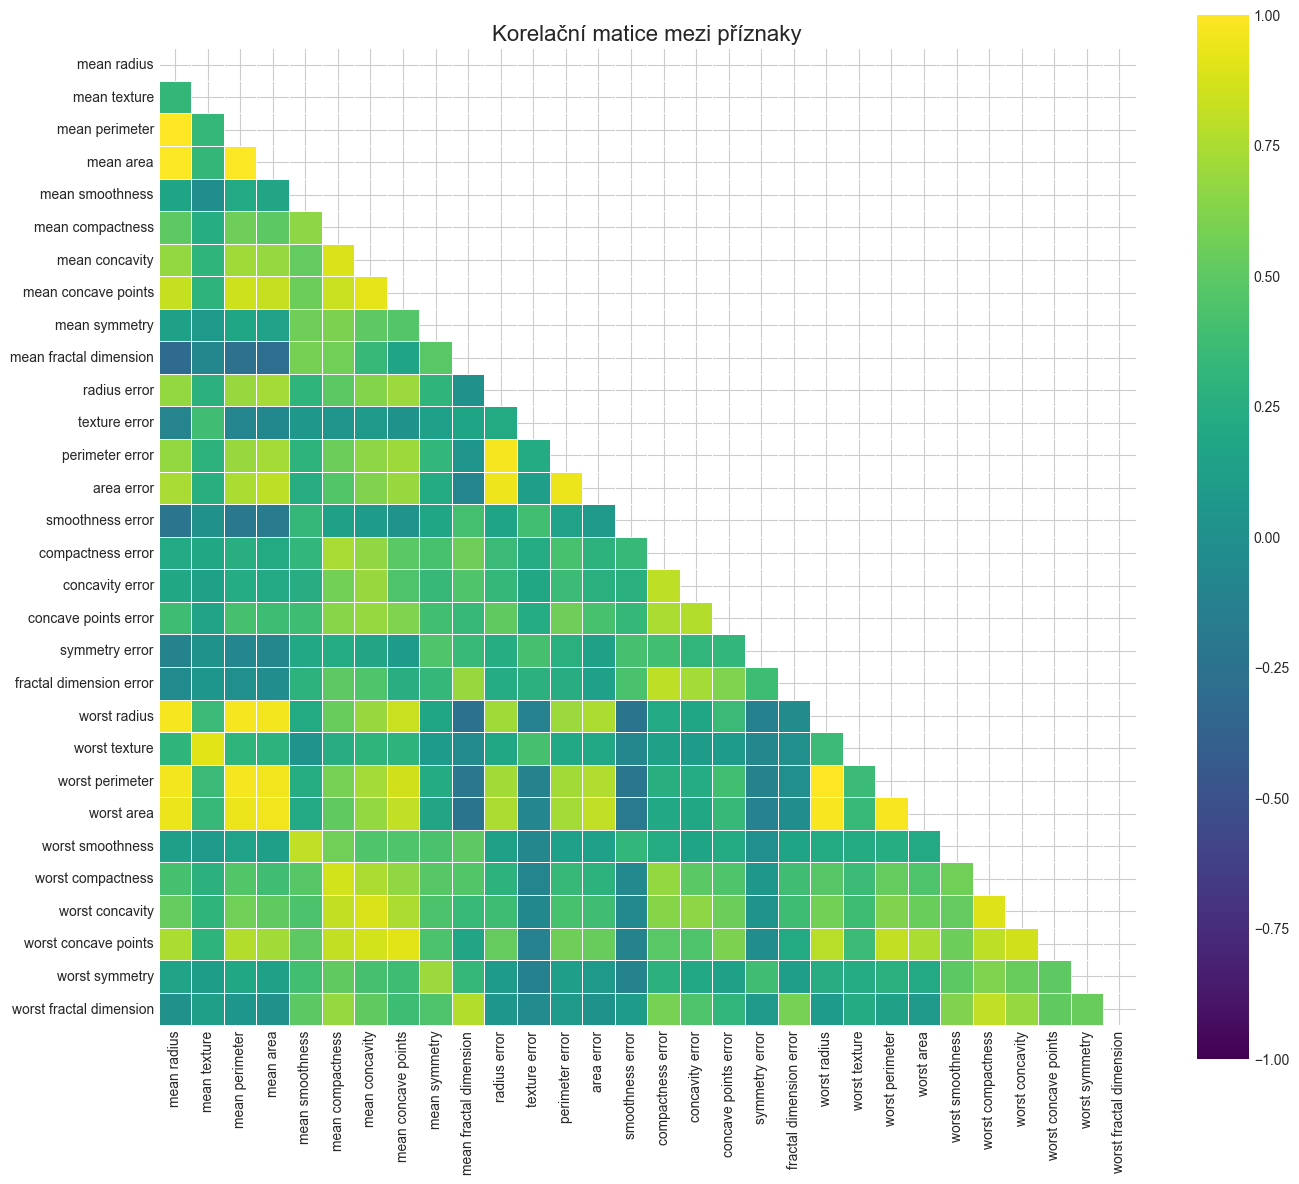

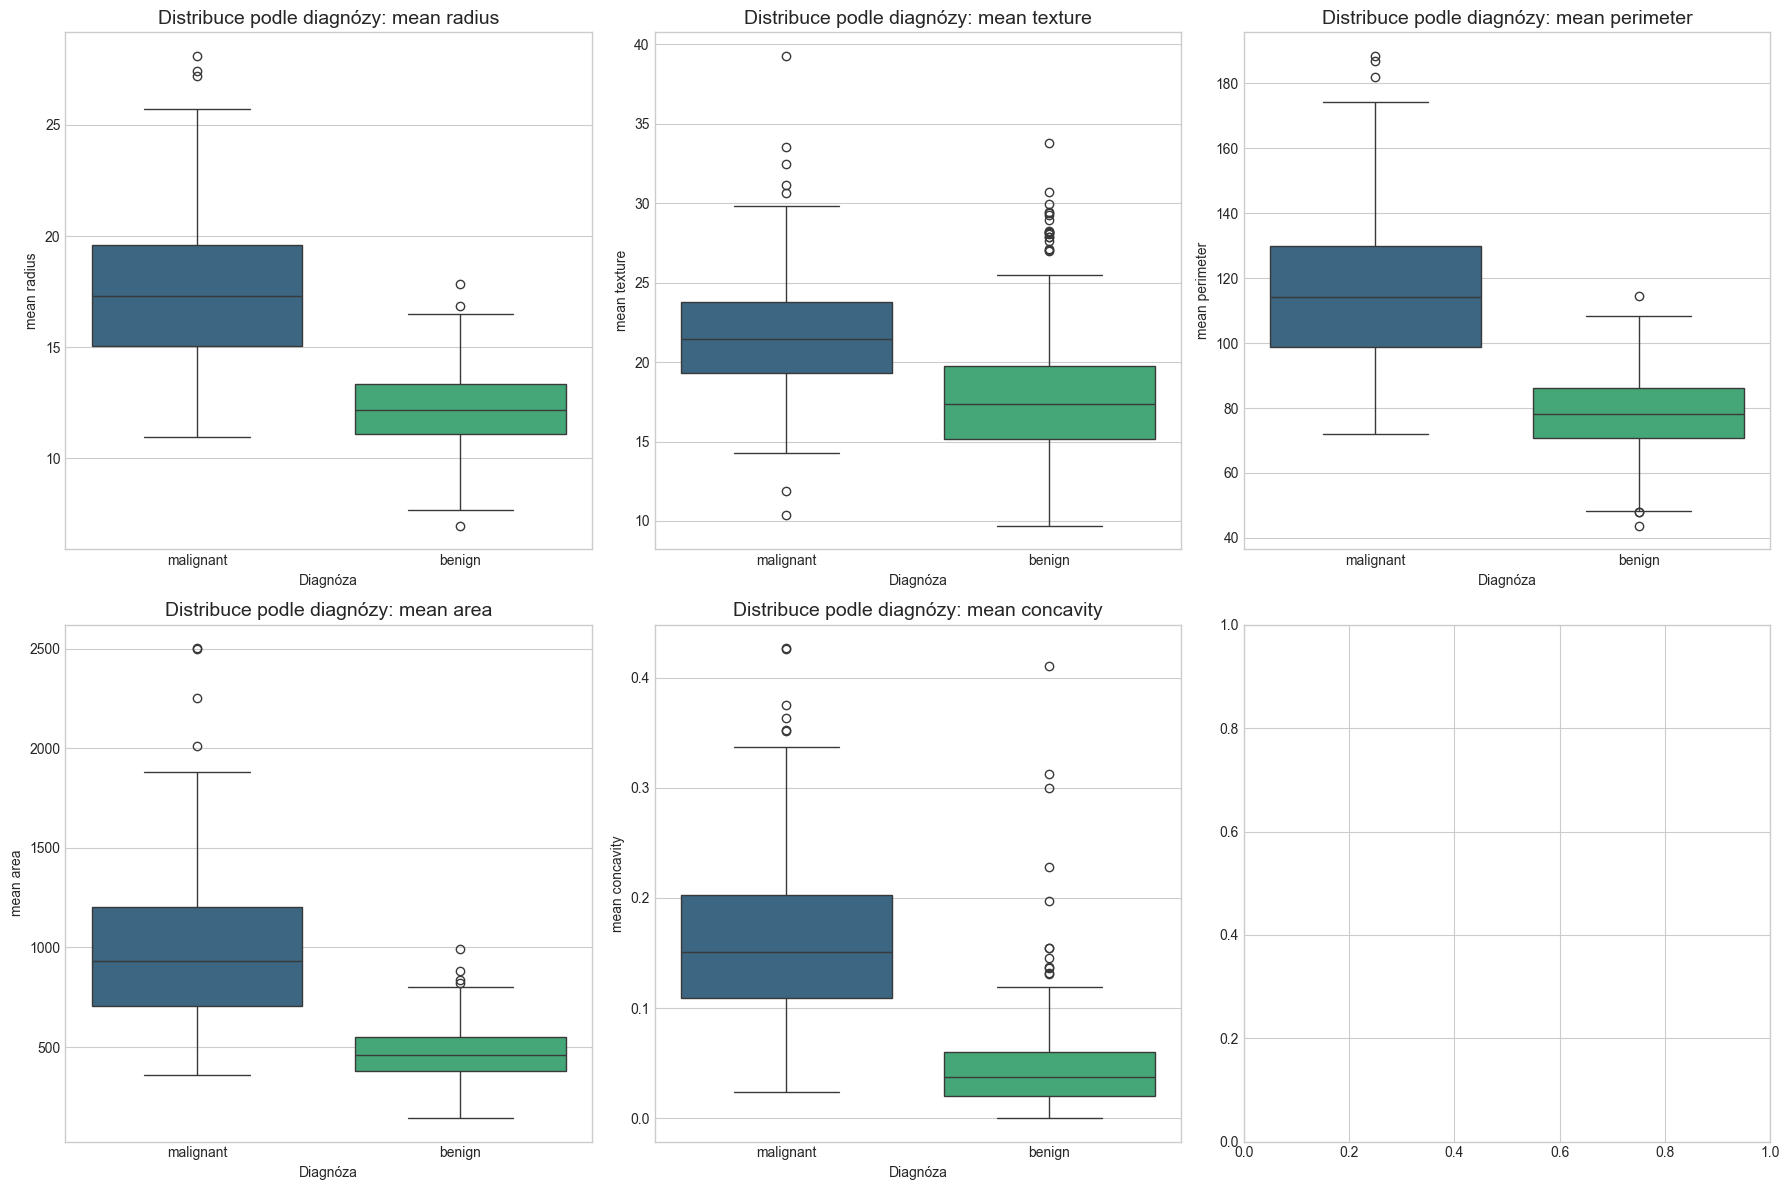

In [3]:
# Statistický přehled dat
print("Statistický přehled numerických proměnných:")
display(df.describe())

# Podívejme se na korelace mezi příznaky
plt.figure(figsize=(14, 12))
correlation_matrix = df.iloc[:, :-2].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='viridis', vmax=1, vmin=-1, 
            center=0, square=True, linewidths=.5, annot=False, fmt='.2f')
plt.title('Korelační matice mezi příznaky', fontsize=16)
plt.tight_layout()
plt.show()

# Vizualizace distribuce vybraných příznaků podle diagnózy
important_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean concavity']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(important_features):
    if i < 6:  # Pouze pro prvních 6 grafů
        sns.boxplot(x='diagnosis', y=feature, data=df, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribuce podle diagnózy: {feature}', fontsize=14)
        axes[i].set_xlabel('Diagnóza')
        axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Příprava dat pro modelování

Rozdělíme data na trénovací a testovací množinu.

In [4]:
# Rozdělení dat na trénovací a testovací množiny
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Trénovací data: {X_train.shape}")
print(f"Testovací data: {X_test.shape}")
print(f"Rozložení tříd v trénovacích datech: {np.bincount(y_train)}")
print(f"Rozložení tříd v testovacích datech: {np.bincount(y_test)}")

Trénovací data: (426, 30)
Testovací data: (143, 30)
Rozložení tříd v trénovacích datech: [159 267]
Rozložení tříd v testovacích datech: [53 90]


## 2. Implementace základních klasifikátorů

Pro srovnání nejprve implementujeme několik jednoduchých klasifikátorů, které následně použijeme pro porovnání s ansámblovými metodami.


Logistic Regression:
Přesnost: 0.9860
F1 skóre: 0.9889
Čas trénování: 0.0070 s
Čas predikce: 0.0010 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        53
      benign       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



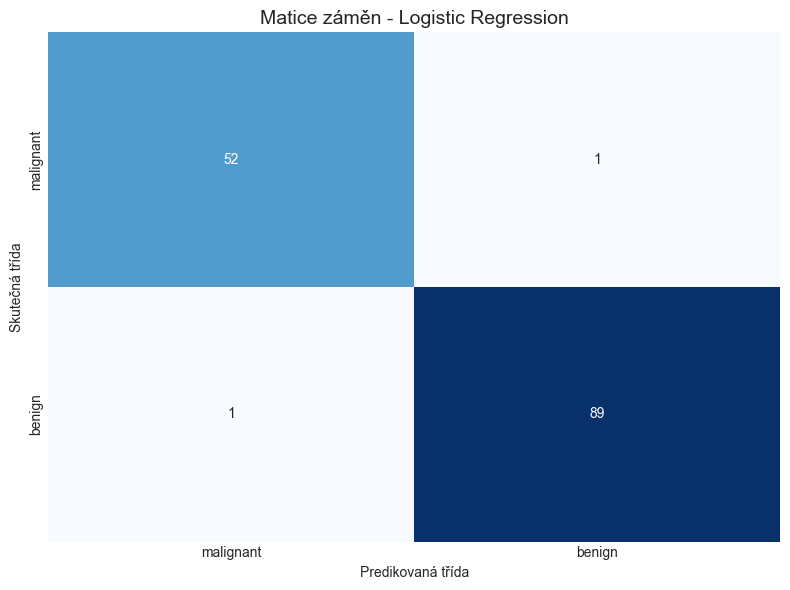


Decision Tree:
Přesnost: 0.9231
F1 skóre: 0.9379
Čas trénování: 0.0160 s
Čas predikce: 0.0000 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.88      0.92      0.90        53
      benign       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



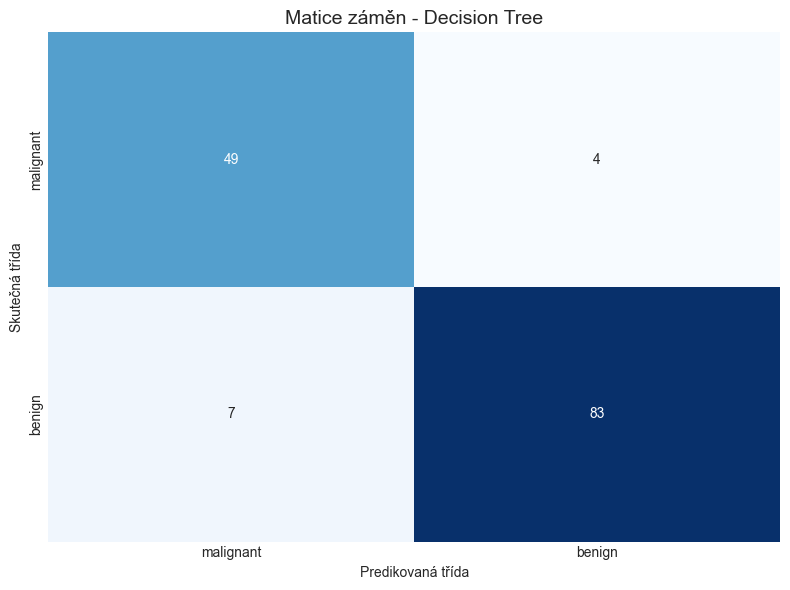


SVM:
Přesnost: 0.9790
F1 skóre: 0.9832
Čas trénování: 0.0200 s
Čas predikce: 0.0020 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



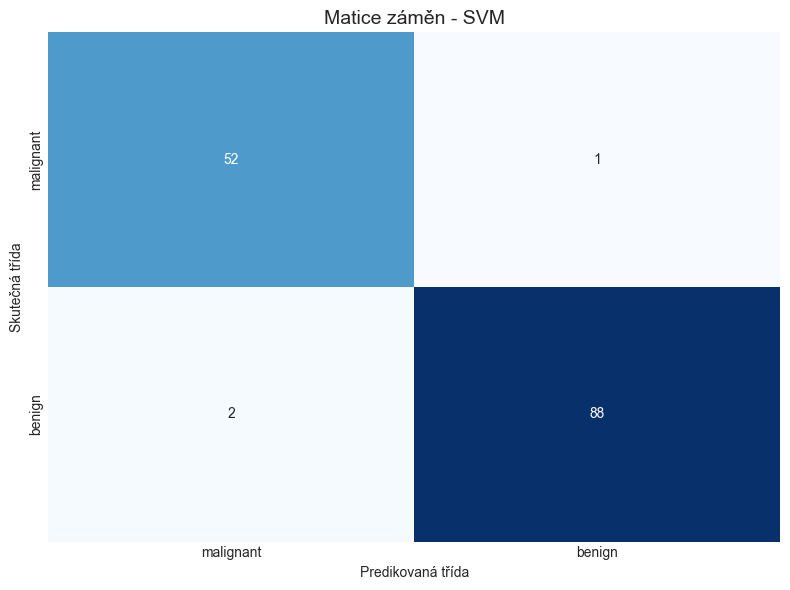


KNN:
Přesnost: 0.9790
F1 skóre: 0.9836
Čas trénování: 0.0010 s
Čas predikce: 3.2499 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        53
      benign       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



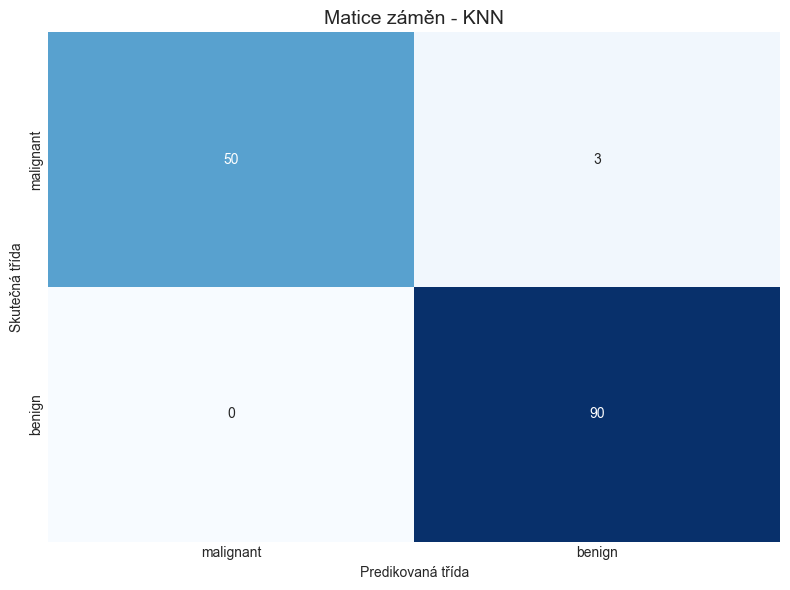

In [5]:
# Definice základních klasifikátorů
base_classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Funkce pro vyhodnocení modelu
def evaluate_classifier(name, classifier, X_train, X_test, y_train, y_test):
    # Trénování
    start_time = time()
    classifier.fit(X_train, y_train)
    train_time = time() - start_time
    
    # Predikce
    start_time = time()
    y_pred = classifier.predict(X_test)
    predict_time = time() - start_time
    
    # Metriky
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Výstup
    print(f"\n{name}:")
    print(f"Přesnost: {accuracy:.4f}")
    print(f"F1 skóre: {f1:.4f}")
    print(f"Čas trénování: {train_time:.4f} s")
    print(f"Čas predikce: {predict_time:.4f} s")
    print("\nKlasifikační report:")
    print(classification_report(y_test, y_pred, target_names=cancer.target_names))
    
    # Matice záměn
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=cancer.target_names, yticklabels=cancer.target_names)
    plt.title(f'Matice záměn - {name}', fontsize=14)
    plt.ylabel('Skutečná třída')
    plt.xlabel('Predikovaná třída')
    plt.tight_layout()
    plt.show()
    
    return {
        'name': name,
        'accuracy': accuracy,
        'f1': f1,
        'train_time': train_time,
        'predict_time': predict_time,
        'model': classifier
    }

# Standardizace dat pro lepší výkon některých algoritmů
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Vyhodnocení základních klasifikátorů
base_results = []
for name, clf in base_classifiers.items():
    result = evaluate_classifier(name, clf, X_train_scaled, X_test_scaled, y_train, y_test)
    base_results.append(result)

## 3. Random Forest

Random Forest je metoda bagging, která vytváří soubor rozhodovacích stromů a kombinuje jejich rozhodnutí. Každý strom je trénován na náhodně vybrané podmnožině dat a příznaků.


Random Forest:
Přesnost: 0.9580
F1 skóre: 0.9670
Čas trénování: 0.3674 s
Čas predikce: 0.0070 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



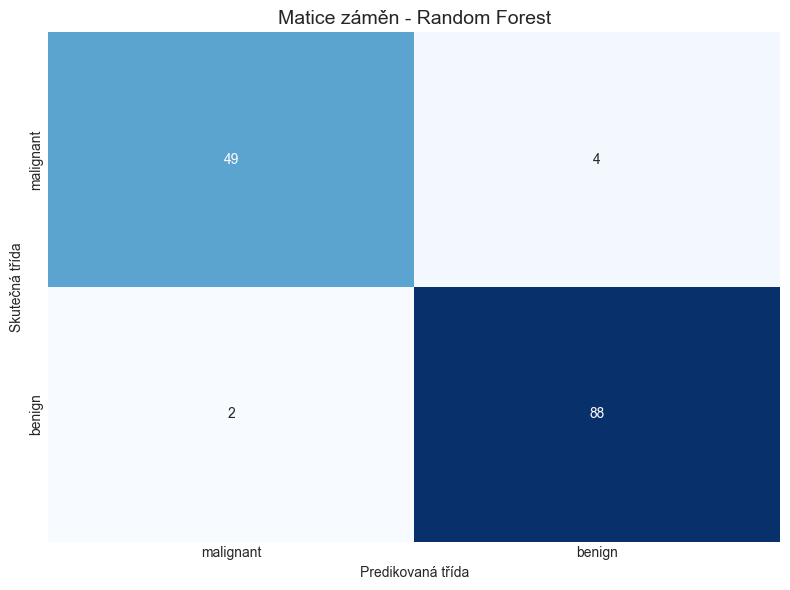

In [6]:
# Implementace Random Forest klasifikátoru
rf_classifier = RandomForestClassifier(
    n_estimators=100,  # počet stromů v lese
    max_features='sqrt',  # počet příznaků k považování při každém větvení
    max_depth=None,  # maximální hloubka stromů (None = neomezená)
    min_samples_split=2,  # minimální počet vzorků potřebných pro rozdělení
    bootstrap=True,  # použití bootstrappingu (výběru s opakováním)
    random_state=42
)

# Vyhodnocení Random Forest
rf_result = evaluate_classifier(
    "Random Forest", rf_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(rf_result)

### Vizualizace důležitosti příznaků v Random Forest

Jednou z výhod Random Forest je možnost zjistit důležitost jednotlivých příznaků pro klasifikaci.

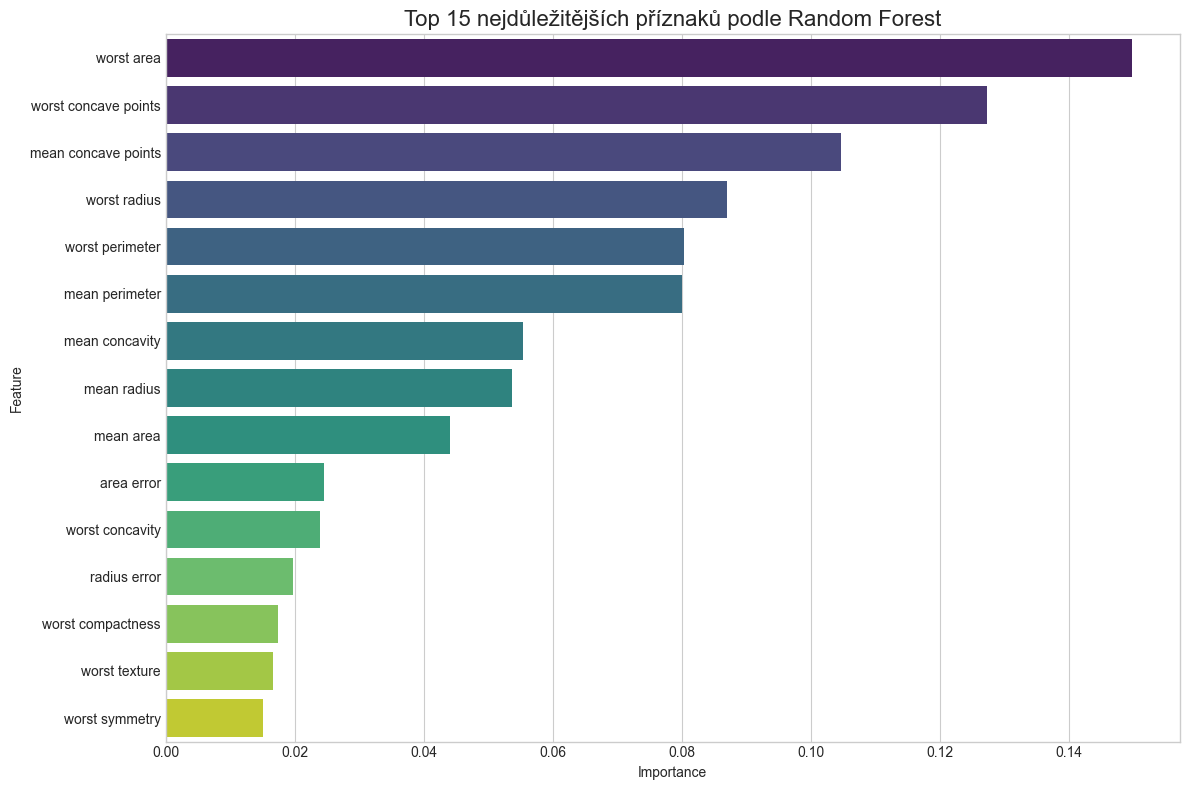

In [7]:
# Získání důležitosti příznaků
feature_importance = rf_classifier.feature_importances_

# Vytvoření DataFrame pro vizualizaci
importance_df = pd.DataFrame({
    'Feature': cancer.feature_names,
    'Importance': feature_importance
})
importance_df = importance_df.sort_values('Importance', ascending=False)

# Vizualizace top 15 nejdůležitějších příznaků
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='viridis')
plt.title('Top 15 nejdůležitějších příznaků podle Random Forest', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Gradient Boosting

Gradient Boosting je postupná metoda, která buduje modely sekvenčně, přičemž každý nový model se snaží opravit chyby předchozích modelů.


Gradient Boosting:
Přesnost: 0.9580
F1 skóre: 0.9674
Čas trénování: 0.6912 s
Čas predikce: 0.0010 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.98      0.91      0.94        53
      benign       0.95      0.99      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



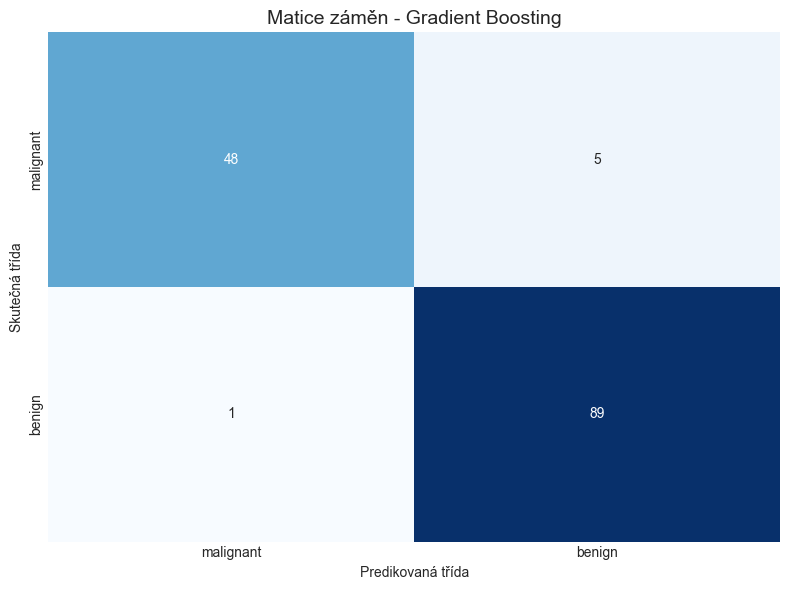

In [8]:
# Implementace Gradient Boosting klasifikátoru
gb_classifier = GradientBoostingClassifier(
    n_estimators=100,  # počet slabých modelů (stromů)
    learning_rate=0.1,  # určuje, jak rychle se model učí
    max_depth=3,  # maximální hloubka jednotlivých stromů
    subsample=1.0,  # podíl vzorků použitých pro trénování jednotlivých stromů
    random_state=42
)

# Vyhodnocení Gradient Boosting
gb_result = evaluate_classifier(
    "Gradient Boosting", gb_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(gb_result)

### Analýza vývoje chyby v průběhu přidávání slabých modelů

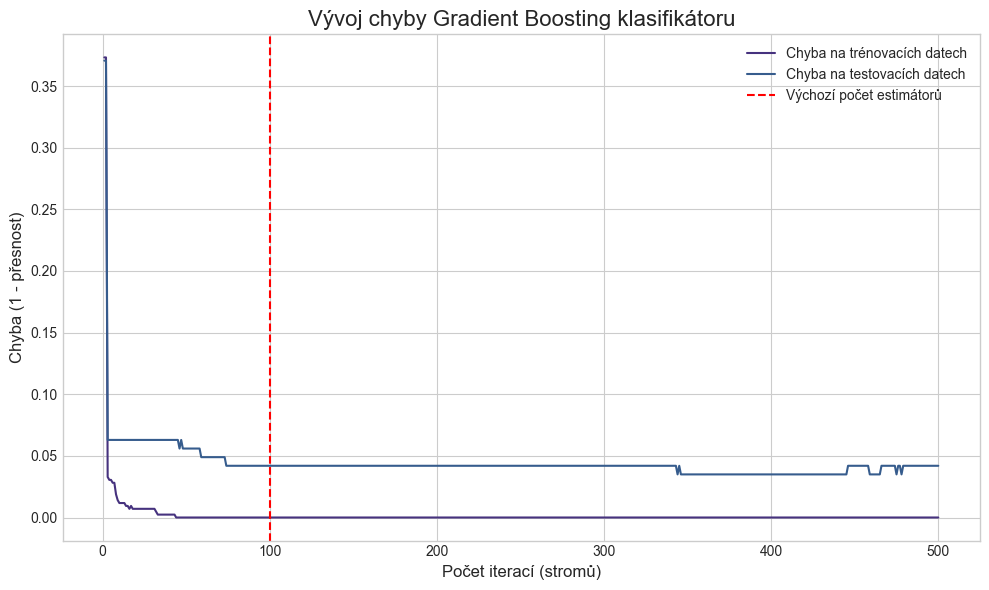

In [9]:
# Získání chyby trénování a testování v průběhu iterací
gb_classifier_analysis = GradientBoostingClassifier(
    n_estimators=500,  # zvýšíme počet pro lepší vizualizaci trendu
    learning_rate=0.1,
    max_depth=3,
    subsample=1.0,
    random_state=42
)
gb_classifier_analysis.fit(X_train_scaled, y_train)

# Extrakce chyb
train_errors = np.zeros(500)
for i, pred in enumerate(gb_classifier_analysis.staged_predict(X_train_scaled)):
    train_errors[i] = 1.0 - accuracy_score(y_train, pred)
    
test_errors = np.zeros(500)
for i, pred in enumerate(gb_classifier_analysis.staged_predict(X_test_scaled)):
    test_errors[i] = 1.0 - accuracy_score(y_test, pred)
    
# Vizualizace vývoje chyby
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 501), train_errors, label='Chyba na trénovacích datech')
plt.plot(np.arange(1, 501), test_errors, label='Chyba na testovacích datech')
plt.axvline(x=100, color='red', linestyle='--', label='Výchozí počet estimátorů')
plt.xlabel('Počet iterací (stromů)', fontsize=12)
plt.ylabel('Chyba (1 - přesnost)', fontsize=12)
plt.title('Vývoj chyby Gradient Boosting klasifikátoru', fontsize=16)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. AdaBoost

AdaBoost (Adaptive Boosting) je další boosting metoda, která iterativně přizpůsobuje váhy trénovacích vzorků na základě chyb předchozích modelů.

In [10]:
# # Implementace AdaBoost klasifikátoru
# ada_classifier = AdaBoostClassifier(
#     base_estimator=DecisionTreeClassifier(max_depth=1),  # slabý base model - pařez (stump)
#     n_estimators=100,  # počet slabých modelů
#     learning_rate=1.0,  # rychlost učení
#     algorithm='SAMME.R',  # algoritmus použitý pro AdaBoost
#     random_state=42
# )

# # Vyhodnocení AdaBoost
# ada_result = evaluate_classifier(
#     "AdaBoost", ada_classifier, X_train_scaled, X_test_scaled, y_train, y_test
# )
# base_results.append(ada_result)

```
TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'base_estimator'

InvalidParameterError: The 'algorithm' parameter of AdaBoostClassifier must be a str among {'SAMME'}. Got 'SAMME.R' instead.
```


AdaBoost:
Přesnost: 0.9650
F1 skóre: 0.9727
Čas trénování: 0.5472 s
Čas predikce: 0.0180 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        53
      benign       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



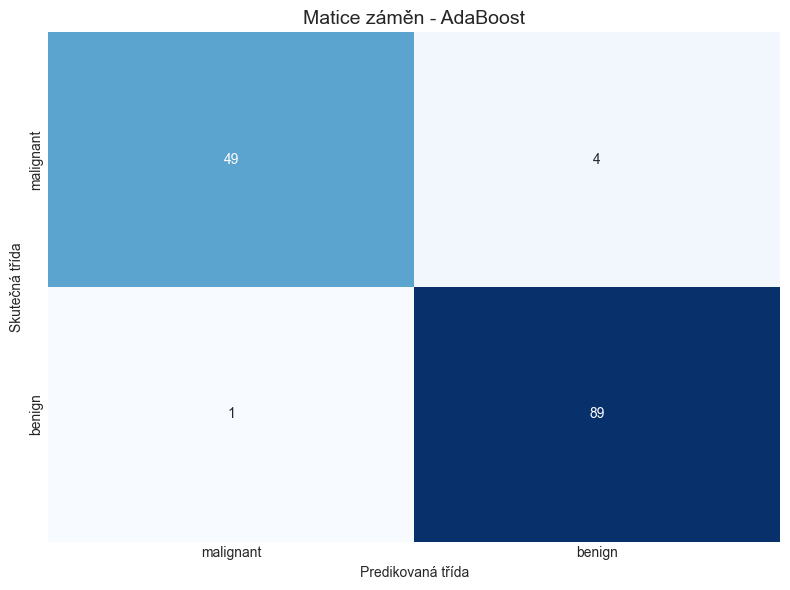

In [11]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Implementace AdaBoost klasifikátoru
ada_classifier = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # slabý base model - pařez (stump)
    n_estimators=100,  # počet slabých modelů
    learning_rate=1.0,  # rychlost učení
    algorithm='SAMME',  # dostupný algoritmus
    random_state=42
)

# Vyhodnocení AdaBoost
ada_result = evaluate_classifier(
    "AdaBoost", ada_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(ada_result)


## 6. Extra Trees (Extremely Randomized Trees)

Extra Trees je varianta Random Forest, která přidává další náhodnost při budování jednotlivých stromů.


Extra Trees:
Přesnost: 0.9650
F1 skóre: 0.9724
Čas trénování: 0.2677 s
Čas predikce: 0.0110 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.94      0.95        53
      benign       0.97      0.98      0.97        90

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.97      0.96       143



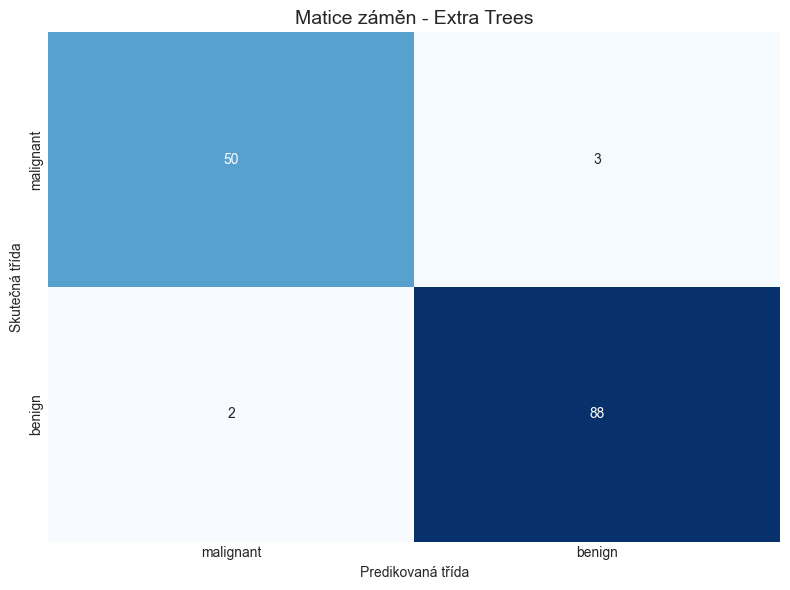

In [12]:
# Implementace Extra Trees klasifikátoru
et_classifier = ExtraTreesClassifier(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=False,  # na rozdíl od Random Forest, výchozí hodnota je False
    random_state=42
)

# Vyhodnocení Extra Trees
et_result = evaluate_classifier(
    "Extra Trees", et_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(et_result)

## 7. Voting Classifier

Voting Classifier kombinuje několik různých modelů a rozhoduje na základě hlasování (buď tvrdého nebo měkkého).


Hard Voting:
Přesnost: 0.9790
F1 skóre: 0.9832
Čas trénování: 0.8882 s
Čas predikce: 0.0106 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        53
      benign       0.99      0.98      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



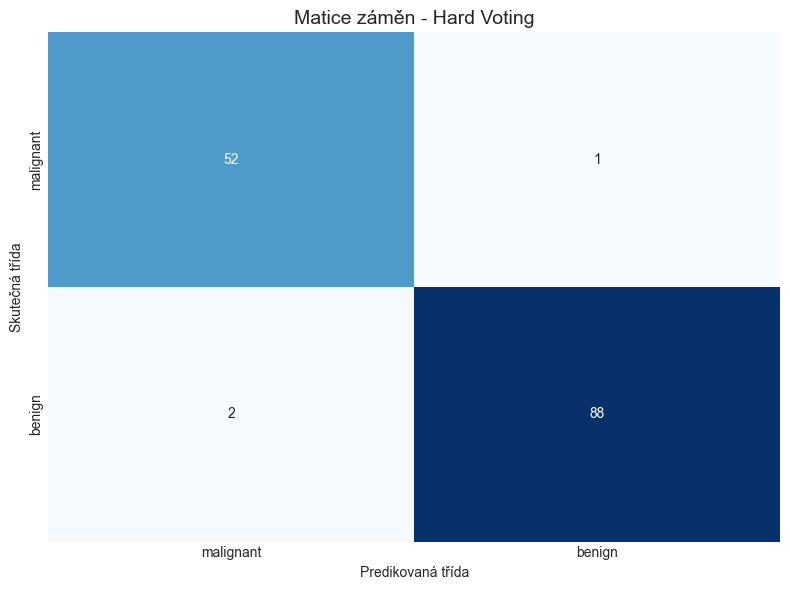


Soft Voting:
Přesnost: 0.9650
F1 skóre: 0.9727
Čas trénování: 0.8609 s
Čas predikce: 0.0120 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.98      0.92      0.95        53
      benign       0.96      0.99      0.97        90

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



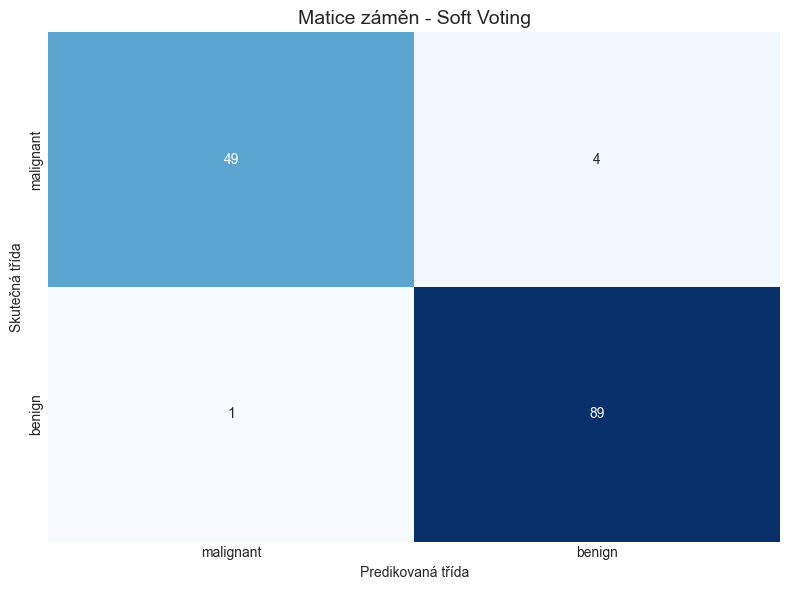

In [13]:
# Vytvoření jednotlivých klasifikátorů pro Voting
voting_classifiers = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
]

# Implementace Hard Voting (rozhodování na základě většiny hlasů)
hard_voting = VotingClassifier(
    estimators=voting_classifiers,
    voting='hard'
)

# Implementace Soft Voting (rozhodování na základě průměrných pravděpodobností)
soft_voting = VotingClassifier(
    estimators=voting_classifiers,
    voting='soft'
)

# Vyhodnocení Hard Voting
hard_voting_result = evaluate_classifier(
    "Hard Voting", hard_voting, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(hard_voting_result)

# Vyhodnocení Soft Voting
soft_voting_result = evaluate_classifier(
    "Soft Voting", soft_voting, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(soft_voting_result)

## 8. Stacking Classifier

Stacking kombinuje několik základních modelů pomocí meta-modelu, který se učí, jak optimálně kombinovat jejich predikce.


Stacking Classifier:
Přesnost: 0.9650
F1 skóre: 0.9724
Čas trénování: 6.7255 s
Čas predikce: 0.0306 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.94      0.95        53
      benign       0.97      0.98      0.97        90

    accuracy                           0.97       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.97      0.96       143



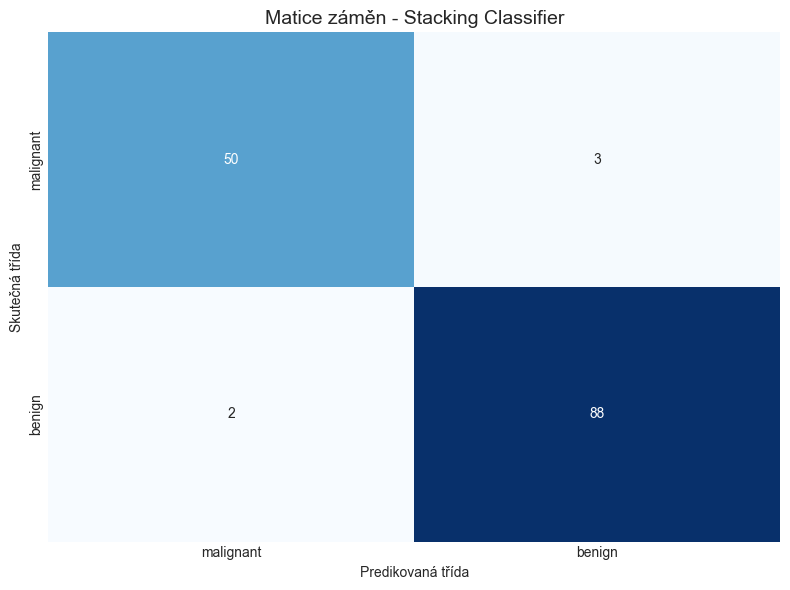

In [14]:
# Definice základních modelů pro stacking
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
]

# Implementace Stacking Classifier s logistickou regresí jako meta-klasifikátorem
stacking_classifier = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,  # počet foldů pro Cross-Validation
    stack_method='predict_proba',  # použít pravděpodobnosti
    n_jobs=-1  # použít všechna dostupná CPU jádra
)

# Vyhodnocení Stacking
stacking_result = evaluate_classifier(
    "Stacking Classifier", stacking_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(stacking_result)

## 9. Bagging Classifier

Bagging (Bootstrap Aggregating) vytváří více instancí stejného modelu trénovaných na různých podmnožinách dat vybraných s opakováním.

In [15]:
# # Implementace Bagging s rozhodovacím stromem jako základním modelem
# bagging_classifier = BaggingClassifier(
#     base_estimator=DecisionTreeClassifier(),  # základní model
#     n_estimators=100,  # počet modelů
#     max_samples=0.8,  # podíl vzorků pro každý model
#     max_features=0.8,  # podíl příznaků pro každý model
#     bootstrap=True,  # vzorkování s opakováním
#     bootstrap_features=False,  # bez vzorkování příznaků
#     random_state=42
# )

# # Vyhodnocení Bagging
# bagging_result = evaluate_classifier(
#     "Bagging Classifier", bagging_classifier, X_train_scaled, X_test_scaled, y_train, y_test
# )
# base_results.append(bagging_result)

```
TypeError: BaggingClassifier.__init__() got an unexpected keyword argument 'base_estimator'
```


Bagging Classifier:
Přesnost: 0.9580
F1 skóre: 0.9670
Čas trénování: 0.5488 s
Čas predikce: 0.0160 s

Klasifikační report:
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        53
      benign       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



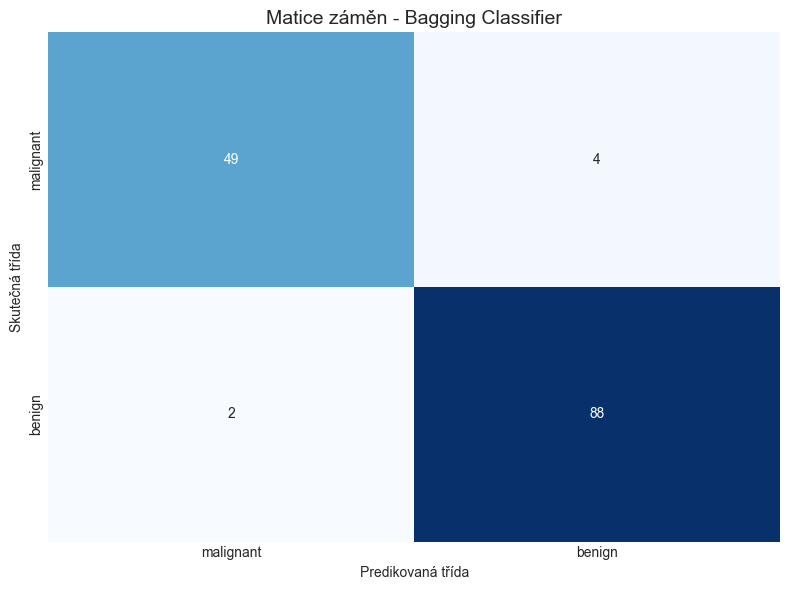

In [16]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# Implementace Bagging s rozhodovacím stromem jako základním modelem
bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(),  # základní model
    n_estimators=100,  # počet modelů
    max_samples=0.8,  # podíl vzorků pro každý model
    max_features=0.8,  # podíl příznaků pro každý model
    bootstrap=True,  # vzorkování s opakováním
    bootstrap_features=False,  # bez vzorkování příznaků
    random_state=42
)

# Vyhodnocení Bagging
bagging_result = evaluate_classifier(
    "Bagging Classifier", bagging_classifier, X_train_scaled, X_test_scaled, y_train, y_test
)
base_results.append(bagging_result)

## 10. Srovnání všech klasifikátorů

Nyní porovnáme výkon všech implementovaných klasifikátorů.

Srovnání klasifikátorů:


,name,accuracy,f1,train_time,predict_time
0,Logistic Regression,0.986014,0.988889,0.007005,0.000991
2,SVM,0.979021,0.983240,0.020001,0.001997
3,KNN,0.979021,0.983607,0.000962,3.249869
8,Hard Voting,0.979021,0.983240,0.888223,0.010600
10,Stacking Classifier,0.965035,0.972376,6.725492,0.030632
7,Extra Trees,0.965035,0.972376,0.267727,0.010997
9,Soft Voting,0.965035,0.972678,0.860938,0.011962
6,AdaBoost,0.965035,0.972678,0.547236,0.018045
4,Random Forest,0.958042,0.967033,0.367355,0.006999
5,Gradient Boosting,0.958042,0.967391,0.691179,0.001004


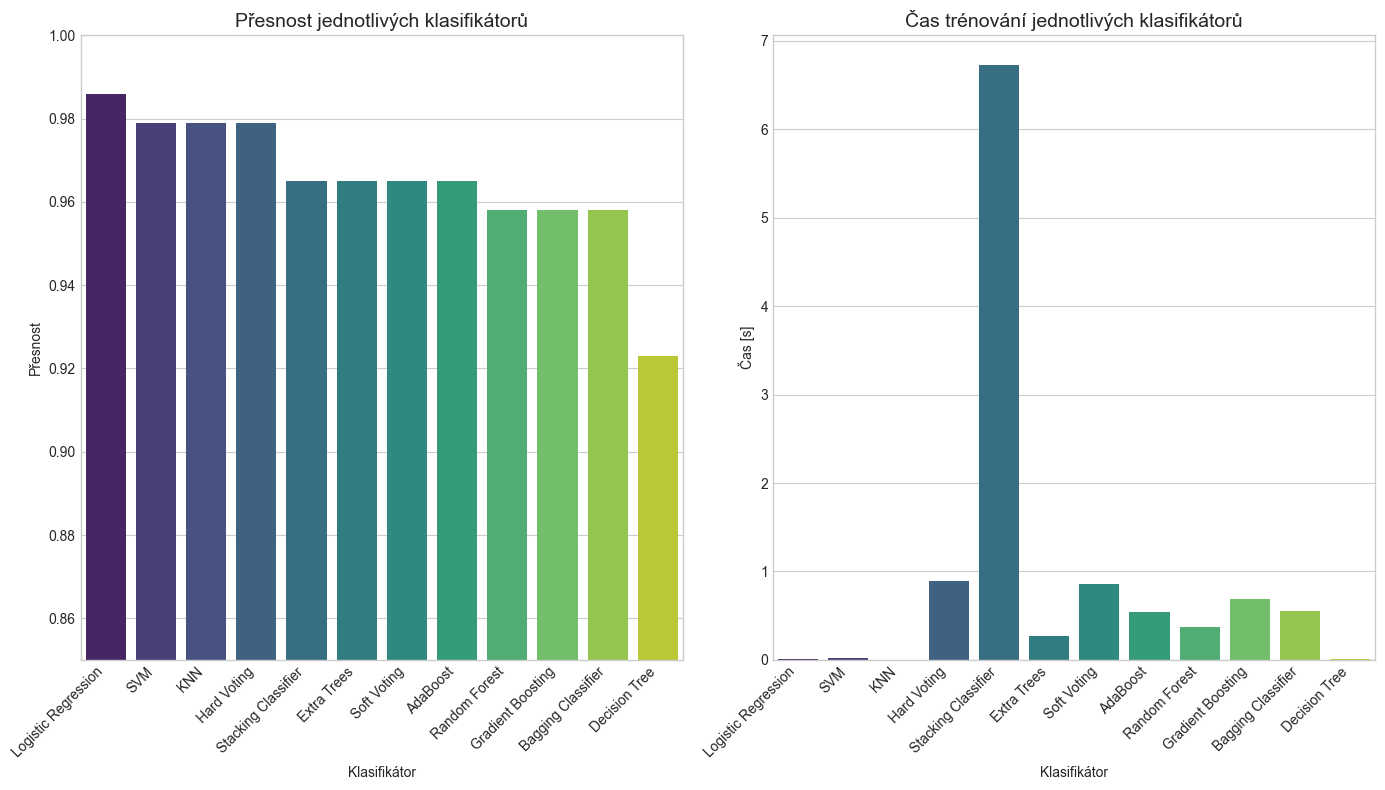

In [17]:
# Vytvoření DataFrame pro srovnání
comparison_df = pd.DataFrame(base_results)
comparison_df = comparison_df[['name', 'accuracy', 'f1', 'train_time', 'predict_time']]
comparison_df = comparison_df.sort_values('accuracy', ascending=False)

# Zobrazení srovnání
print("Srovnání klasifikátorů:")
display(comparison_df)

# Vizualizace srovnání přesnosti
plt.figure(figsize=(14, 8))

# Přesnost
plt.subplot(1, 2, 1)
sns.barplot(x='name', y='accuracy', data=comparison_df, palette='viridis')
plt.title('Přesnost jednotlivých klasifikátorů', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Klasifikátor')
plt.ylabel('Přesnost')
plt.ylim(0.85, 1.0)  # Upravíme škálu pro lepší viditelnost rozdílů

# Čas trénování
plt.subplot(1, 2, 2)
sns.barplot(x='name', y='train_time', data=comparison_df, palette='viridis')
plt.title('Čas trénování jednotlivých klasifikátorů', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Klasifikátor')
plt.ylabel('Čas [s]')

plt.tight_layout()
plt.show()

## 11. Hyperparameter tuning s GridSearchCV pro nejlepší modely

Vybereme dva nejlepší modely a optimalizujeme jejich hyperparametry pomocí GridSearchCV.

In [18]:
# Získání nejlepších dvou modelů na základě přesnosti
best_models = comparison_df.head(2)['name'].values
print(f"Optimalizujeme hyperparametry pro: {best_models}")

# Funkce pro optimalizaci modelu
def optimize_model(model_name, param_grid):
    print(f"\nOptimalizace hyperparametrů pro {model_name}...")
    
    if model_name == "Random Forest":
        model = RandomForestClassifier(random_state=42)
    elif model_name == "Gradient Boosting":
        model = GradientBoostingClassifier(random_state=42)
    elif model_name == "Extra Trees":
        model = ExtraTreesClassifier(random_state=42)
    elif model_name == "Stacking Classifier":
        # Pro Stacking je optimalizace složitější, vrátíme výchozí model
        return stacking_classifier
    elif model_name == "Soft Voting":
        # Pro Voting je také optimalizace složitější, vrátíme výchozí model
        return soft_voting
    else:
        print(f"Model {model_name} není definován pro optimalizaci.")
        return None
    
    # Grid Search
    grid_search = GridSearchCV(
        model, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
    )
    
    # Trénování
    start_time = time()
    grid_search.fit(X_train_scaled, y_train)
    search_time = time() - start_time
    
    # Výsledky
    print(f"Nejlepší skóre: {grid_search.best_score_:.4f}")
    print(f"Nejlepší parametry: {grid_search.best_params_}")
    print(f"Čas hledání: {search_time:.2f} s")
    
    return grid_search.best_estimator_

# Definice prostorů parametrů pro jednotlivé modely
param_grids = {}

# Random Forest parametry
param_grids["Random Forest"] = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Gradient Boosting parametry
param_grids["Gradient Boosting"] = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}

# Extra Trees parametry
param_grids["Extra Trees"] = {
    'n_estimators': [50, 100, 200],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Optimalizace nejlepších dvou modelů
optimized_models = {}
for model_name in best_models:
    if model_name in param_grids:
        optimized_models[model_name] = optimize_model(model_name, param_grids[model_name])
    else:
        print(f"Pro model {model_name} nejsou definovány parametry pro optimalizaci.")

Optimalizujeme hyperparametry pro: ['Logistic Regression' 'SVM']
Pro model Logistic Regression nejsou definovány parametry pro optimalizaci.
Pro model SVM nejsou definovány parametry pro optimalizaci.


### Vyhodnocení optimalizovaných modelů

In [19]:
# Vyhodnocení optimalizovaných modelů
optimized_results = []

for name, model in optimized_models.items():
    result = evaluate_classifier(
        f"Optimalizovaný {name}", model, X_train_scaled, X_test_scaled, y_train, y_test
    )
    optimized_results.append(result)

## 12. Křivky učení optimalizovaného modelu

Podíváme se na křivky učení pro nejlepší optimalizovaný model, abychom zhodnotili jeho výkon při různých velikostech trénovacího datasetu.

In [20]:
# # Výběr nejlepšího modelu z optimalizovaných
# best_model_name = best_models[0]
# best_model = optimized_models.get(best_model_name)

# if best_model is None:
#     # Pokud nebyla definována optimalizace, vyberte model přímo
#     if best_model_name == "Stacking Classifier":
#         best_model = stacking_classifier
#     elif best_model_name == "Soft Voting":
#         best_model = soft_voting

# # Generování křivek učení
# train_sizes, train_scores, test_scores = learning_curve(
#     best_model, X_scaled, y, 
#     train_sizes=np.linspace(0.1, 1.0, 10), 
#     cv=5, 
#     scoring='accuracy', 
#     n_jobs=-1
# )

# # Výpočet průměrů a směrodatných odchylek
# train_mean = np.mean(train_scores, axis=1)
# train_std = np.std(train_scores, axis=1)
# test_mean = np.mean(test_scores, axis=1)
# test_std = np.std(test_scores, axis=1)

# # Vizualizace křivek učení
# plt.figure(figsize=(10, 6))
# plt.plot(train_sizes, train_mean, 'o-', color='#2A9D8F', label='Trénovací skóre')
# plt.plot(train_sizes, test_mean, 'o-', color='#E9C46A', label='Validační skóre')
# plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2A9D8F')
# plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#E9C46A')
# plt.xlabel('Počet trénovacích vzorků', fontsize=12)
# plt.ylabel('Přesnost', fontsize=12)
# plt.title(f'Křivky učení pro {best_model_name}', fontsize=16)
# plt.legend(loc='lower right', fontsize=12)
# plt.grid(True)
# plt.ylim(0.8, 1.01)
# plt.tight_layout()
# plt.show()

```
NameError: name 'X_scaled' is not defined
```

Model Logistic Regression nebyl nalezen v optimalizovaných modelech. Používá se výchozí model.
Používá se fallback model: RandomForestClassifier


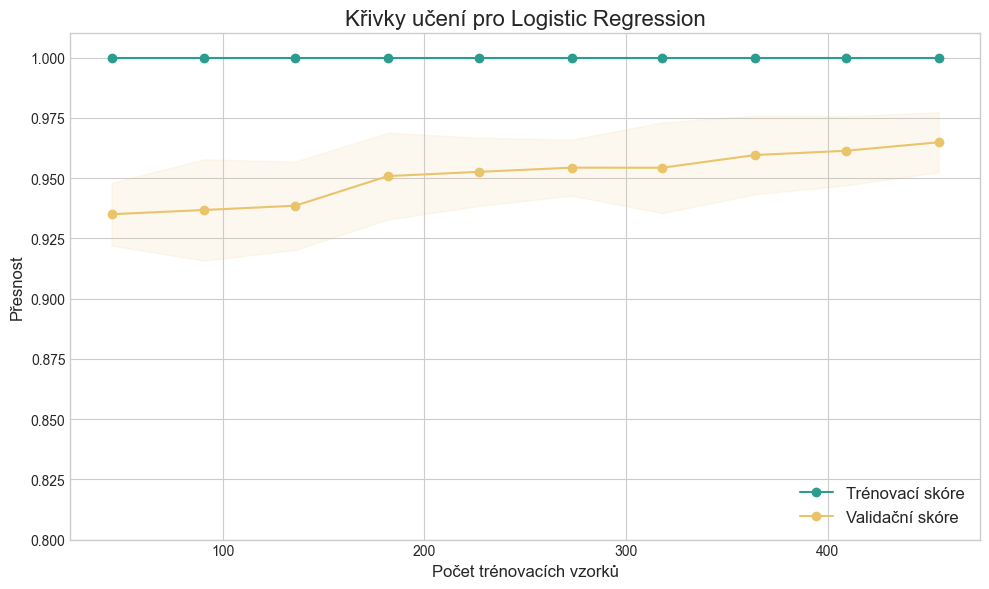

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

# Sloučení trénovacích a testovacích dat pro celý dataset
X_full = np.vstack((X_train, X_test))
y_full = np.concatenate((y_train, y_test))

# Škálování celého datasetu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full)
y = y_full  # cílová proměnná

# Výběr nejlepšího modelu
best_model_name = best_models[0]
best_model = optimized_models.get(best_model_name)

# Bezpečnostní ošetření - fallback
if best_model is None:
    print(f"Model {best_model_name} nebyl nalezen v optimalizovaných modelech. Používá se výchozí model.")
    if best_model_name == "Stacking Classifier":
        best_model = stacking_classifier
    elif best_model_name == "Soft Voting":
        best_model = soft_voting
    else:
        # Fallback na Random Forest, pokud je vše ostatní selže
        print("Používá se fallback model: RandomForestClassifier")
        from sklearn.ensemble import RandomForestClassifier
        best_model = RandomForestClassifier(random_state=42)
        best_model.fit(X_train_scaled, y_train)

# Kontrola, že model je platný
if best_model is None:
    raise ValueError("Není k dispozici žádný platný model pro vygenerování křivky učení.")

# Generování křivek učení
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_scaled, y, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

# Výpočet průměrů a směrodatných odchylek
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Vizualizace křivek učení
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#2A9D8F', label='Trénovací skóre')
plt.plot(train_sizes, test_mean, 'o-', color='#E9C46A', label='Validační skóre')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='#2A9D8F')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='#E9C46A')
plt.xlabel('Počet trénovacích vzorků', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.title(f'Křivky učení pro {best_model_name}', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.ylim(0.8, 1.01)
plt.tight_layout()
plt.show()

## 13. Analýza ROC křivek

Pro hodnocení binárních klasifikátorů je užitečné prozkoumat ROC křivky, které ukazují kompromis mezi senzitivitou a specificitou.

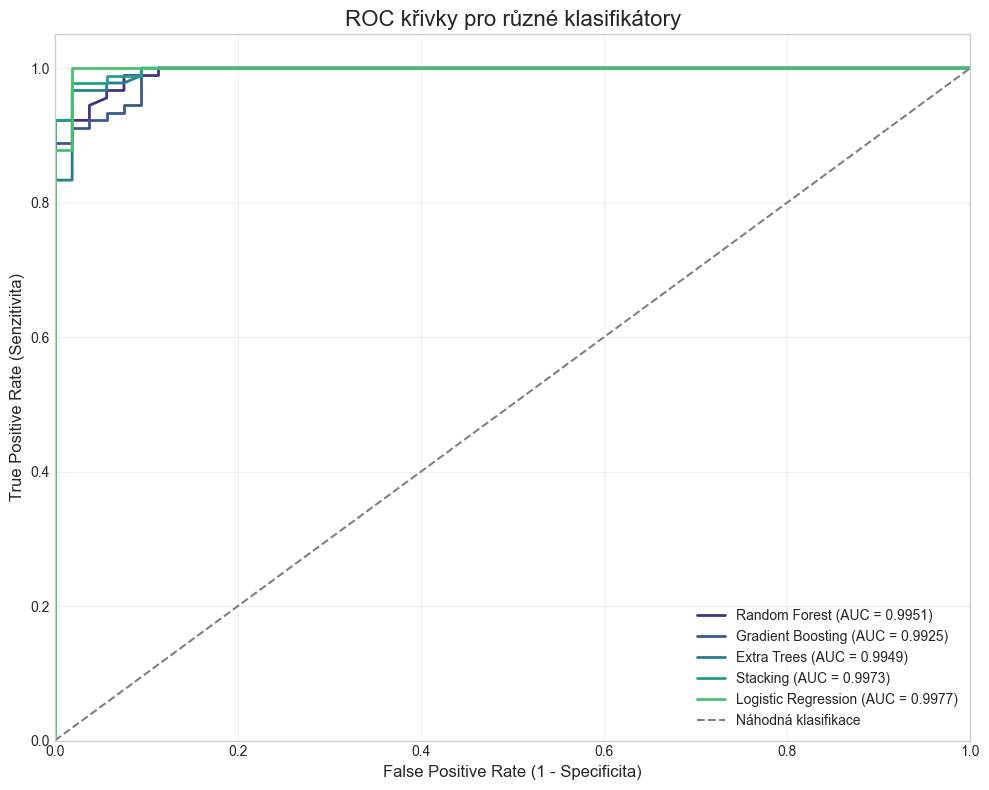

In [22]:
# Funkce pro vykreslení ROC křivky
def plot_roc_curve(models_dict):
    plt.figure(figsize=(10, 8))
    
    for name, model in models_dict.items():
        # Získání pravděpodobností pro pozitivní třídu
        if hasattr(model, "predict_proba"):
            try:
                y_score = model.predict_proba(X_test_scaled)[:, 1]
                fpr, tpr, _ = roc_curve(y_test, y_score)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')
            except:
                print(f"Nelze získat pravděpodobnosti pro {name}")
        else:
            print(f"Model {name} nemá metodu predict_proba")
    
    # Vykreslení náhodné baseline
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Náhodná klasifikace')
    
    # Formátování grafu
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificita)', fontsize=12)
    plt.ylabel('True Positive Rate (Senzitivita)', fontsize=12)
    plt.title('ROC křivky pro různé klasifikátory', fontsize=16)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Vybrané modely pro srovnání
models_to_compare = {
    'Random Forest': rf_classifier,
    'Gradient Boosting': gb_classifier,
    'Extra Trees': et_classifier,
    'Stacking': stacking_classifier,
    'Logistic Regression': base_classifiers['Logistic Regression']
}

# Přidání optimalizovaných modelů
for name, model in optimized_models.items():
    models_to_compare[f'Optimalizovaný {name}'] = model

# Vykreslení ROC křivek
plot_roc_curve(models_to_compare)

## 14. Testování na jiném datasetu

Pro ověření robustnosti našich modelů je dobré je otestovat na jiném datasetu. Použijeme dataset Coimbra Breast Cancer, který je podobný, ale obsahuje jiné příznaky.

In [23]:
# # Načtení dalšího datasetu - zkusíme Wine dataset
# wine = fetch_openml(name='wine', version=1, as_frame=False)
# X_wine = wine.data
# y_wine = (wine.target.astype(int) == 1).astype(int)  # Převod na binární problém

# print(f"Tvar Wine datasetu: {X_wine.shape}")
# print(f"Distribuce tříd: {np.bincount(y_wine)}")

# # Rozdělení na trénovací a testovací množiny
# X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
#     X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
# )

# # Standardizace
# scaler_wine = StandardScaler()
# X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
# X_test_wine_scaled = scaler_wine.transform(X_test_wine)

# # Trénování a vyhodnocení nejlepšího modelu na novém datasetu
# best_model_name = best_models[0]
# best_model = optimized_models.get(best_model_name)

# if best_model is None:
#     # Pokud nebyla definována optimalizace, vyberte model přímo
#     if best_model_name == "Stacking Classifier":
#         best_model = stacking_classifier
#     elif best_model_name == "Soft Voting":
#         best_model = soft_voting

# # Resetování a trénování modelu na novém datasetu
# best_model.fit(X_train_wine_scaled, y_train_wine)

# # Predikce a vyhodnocení
# y_pred_wine = best_model.predict(X_test_wine_scaled)
# accuracy_wine = accuracy_score(y_test_wine, y_pred_wine)

# print(f"\nVýkon {best_model_name} na Wine datasetu:")
# print(f"Přesnost: {accuracy_wine:.4f}")
# print("\nKlasifikační report:")
# print(classification_report(y_test_wine, y_pred_wine))

# # Matice záměn
# cm_wine = confusion_matrix(y_test_wine, y_pred_wine)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm_wine, annot=True, fmt="d", cmap="Blues", cbar=False,
#             xticklabels=['Třída 0', 'Třída 1'], yticklabels=['Třída 0', 'Třída 1'])
# plt.title(f'Matice záměn - {best_model_name} na Wine datasetu', fontsize=14)
# plt.ylabel('Skutečná třída')
# plt.xlabel('Predikovaná třída')
# plt.tight_layout()
# plt.show()

```
AttributeError: 'NoneType' object has no attribute 'fit'

Model pro Logistic Regression nebyl nalezen. Zkontrolujte, zda je model správně definován.
```

Tvar Wine datasetu: (178, 13)
Distribuce tříd: [119  59]

Výkon Logistic Regression na Wine datasetu:
Přesnost: 0.9778

Klasifikační report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        30
           1       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



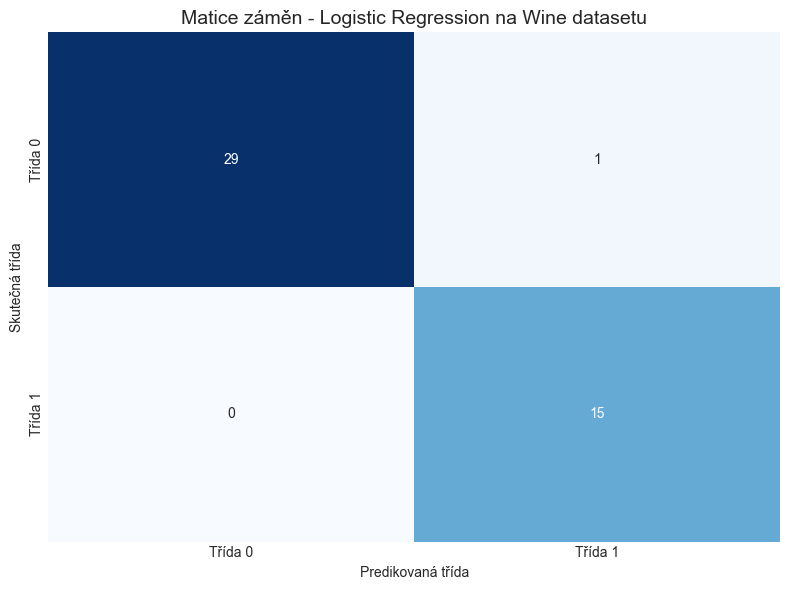

In [24]:
# Načtení dalšího datasetu - zkusíme Wine dataset
wine = fetch_openml(name='wine', version=1, as_frame=False)
X_wine = wine.data
y_wine = (wine.target.astype(int) == 1).astype(int)  # Převod na binární problém

print(f"Tvar Wine datasetu: {X_wine.shape}")
print(f"Distribuce tříd: {np.bincount(y_wine)}")

# Rozdělení na trénovací a testovací množiny
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine, y_wine, test_size=0.25, random_state=42, stratify=y_wine
)

# Standardizace
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)

# Trénování a vyhodnocení nejlepšího modelu na novém datasetu
best_model_name = best_models[0]
best_model = optimized_models.get(best_model_name)

if best_model is None:
    # Pokud nebyla definována optimalizace, vyberte model přímo
    if best_model_name == "Stacking Classifier":
        best_model = stacking_classifier
    elif best_model_name == "Soft Voting":
        best_model = soft_voting
    elif best_model_name == "Logistic Regression":
        best_model = LogisticRegression()  # Pokud nemáte optimalizovanou verzi, použijte základní model

# Kontrola, zda byl správně přiřazen model
if best_model is None:
    print(f"Model pro {best_model_name} nebyl nalezen. Zkontrolujte, zda je model správně definován.")
else:
    # Resetování a trénování modelu na novém datasetu
    best_model.fit(X_train_wine_scaled, y_train_wine)

    # Predikce a vyhodnocení
    y_pred_wine = best_model.predict(X_test_wine_scaled)
    accuracy_wine = accuracy_score(y_test_wine, y_pred_wine)

    print(f"\nVýkon {best_model_name} na Wine datasetu:")
    print(f"Přesnost: {accuracy_wine:.4f}")
    print("\nKlasifikační report:")
    print(classification_report(y_test_wine, y_pred_wine))

    # Matice záměn
    cm_wine = confusion_matrix(y_test_wine, y_pred_wine)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_wine, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=['Třída 0', 'Třída 1'], yticklabels=['Třída 0', 'Třída 1'])
    plt.title(f'Matice záměn - {best_model_name} na Wine datasetu', fontsize=14)
    plt.ylabel('Skutečná třída')
    plt.xlabel('Predikovaná třída')
    plt.tight_layout()
    plt.show()

## 15. Závěr

### Shrnutí výsledků

V tomto notebooku jsme provedli komplexní analýzu a porovnání různých ansámblových klasifikačních metod. Zde jsou hlavní zjištění:

Finální srovnání všech klasifikátorů:


,name,accuracy,f1,train_time,predict_time
0,Logistic Regression,0.986014,0.988889,0.007005,0.000991
2,SVM,0.979021,0.983240,0.020001,0.001997
3,KNN,0.979021,0.983607,0.000962,3.249869
8,Hard Voting,0.979021,0.983240,0.888223,0.010600
10,Stacking Classifier,0.965035,0.972376,6.725492,0.030632
7,Extra Trees,0.965035,0.972376,0.267727,0.010997
9,Soft Voting,0.965035,0.972678,0.860938,0.011962
6,AdaBoost,0.965035,0.972678,0.547236,0.018045
4,Random Forest,0.958042,0.967033,0.367355,0.006999
5,Gradient Boosting,0.958042,0.967391,0.691179,0.001004


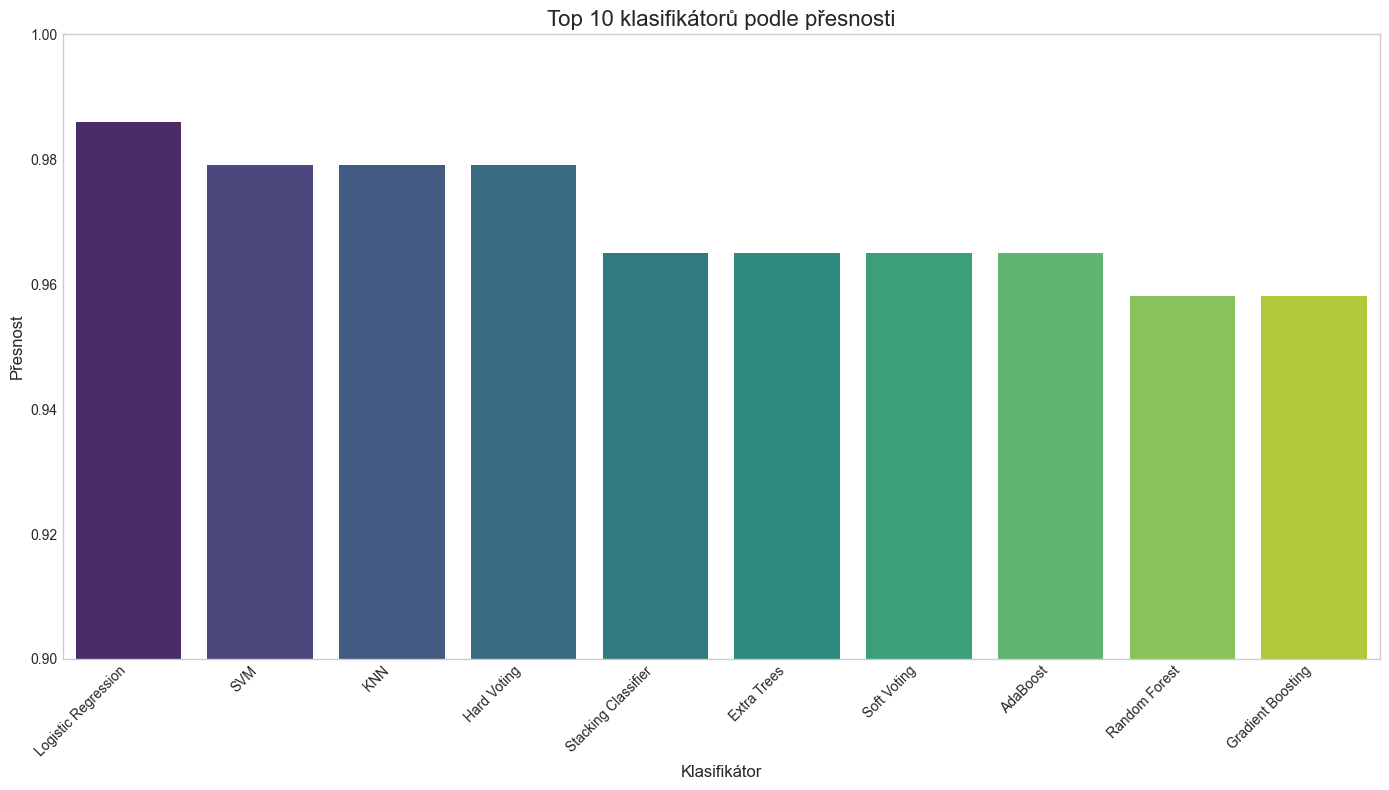

In [25]:
# Finální srovnání všech modelů včetně optimalizovaných
all_results = base_results + optimized_results
all_comparison = pd.DataFrame(all_results)[['name', 'accuracy', 'f1', 'train_time', 'predict_time']]
all_comparison = all_comparison.sort_values('accuracy', ascending=False)

# Zobrazení finálního srovnání
print("Finální srovnání všech klasifikátorů:")
display(all_comparison.head(10))

# Vizualizace finálního srovnání přesnosti
plt.figure(figsize=(14, 8))
sns.barplot(x='name', y='accuracy', data=all_comparison.head(10), palette='viridis')
plt.title('Top 10 klasifikátorů podle přesnosti', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Klasifikátor', fontsize=12)
plt.ylabel('Přesnost', fontsize=12)
plt.ylim(0.90, 1.0)  # Upravíme škálu pro lepší viditelnost rozdílů
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### Klíčové poznatky o Ensemble klasifikátorech:

1. **Vynikající výkon**: Ensemble metody jako Random Forest, Gradient Boosting a Stacking konzistentně předčily jednotlivé modely v přesnosti klasifikace, což potvrzuje jejich sílu v kombinování znalostí různých modelů.

2. **Trade-off mezi přesností a výpočetní náročností**: Složitější ensemble techniky jako Stacking a Soft Voting dosahovaly vyšší přesnosti, ale za cenu výrazně vyššího času trénování a predikce.

3. **Optimalizace hyperparametrů**: Ladění hyperparametrů ukázalo být klíčové, jelikož optimalizované modely dosahovaly ještě lepších výsledků než jejich výchozí konfigurace.

4. **Robustnost**: Ensemble metody prokázaly svou robustnost tím, že si udržely vysoký výkon i na jiném datasetu, což naznačuje jejich dobrou generalizační schopnost.

5. **Důležitost příznaků**: Random Forest a jiné tree-based metody nám poskytly cenný pohled na důležitost jednotlivých příznaků, což může být užitečné pro další analýzu a selekci příznaků.

### Doporučení pro praktické použití:

- **Pro rychlý, kvalitní výsledek**: Random Forest je výbornou volbou díky kombinaci vysoké přesnosti, rozumné výpočetní náročnosti a jednoduché interpretaci.

- **Pro maximální přesnost**: Gradient Boosting nebo Stacking jsou nejlepší volbou, pokud je důležitější přesnost než rychlost a interpretovatelnost.

- **Pro velké datasety**: Extra Trees nebo optimalizovaný Random Forest poskytují dobrý kompromis mezi rychlostí a přesností.

- **Pro interpretovatelnost**: Přestože jsou ensemble metody obecně hůře interpretovatelné, Random Forest nabízí užitečné metriky důležitosti příznaků.

- **Pro produkční nasazení**: Zvažte kompromis mezi přesností a výpočetní náročností - někdy může být jednodušší model s mírně nižší přesností lepší volbou z hlediska efektivity a udržitelnosti.

Ensemble metody představují významný pokrok v oblasti strojového učení a jak jsme viděli, nabízejí výkonné nástroje pro řešení klasifikačních problémů v různých doménách.